## Fitting Demo

This notebook demonstrates the `PhysComp.fitting` module, which fits a two-component periodic model:

**f(x) = A₁sin(x + φ₁) + A₂sin(2x + φ₂) + C**

### Functions covered:
- `fitting.periodic` — model function
- `fitting.periodic_fit` — fit a single signal
- `fitting.periodic_fit_whole` — fit an entire 3D dataset pixel-by-pixel

In [9]:
## Required imports for functions
from tqdm import tqdm
import numpy as np

## Import for plotting
import matplotlib.pyplot as plt

## Simulation function import 
import PhysComp.sim as sim

## Actual fitting import
import PhysComp.fitting as fit

#### The periodic function produces a two component perodic model for a given position x and parameters in form [$A_1$,$\phi_1$,$A_2$,$\phi_2$,$C$] :
### f(x) = $A_1$ sin (x + $\phi_1$) + $A_2$ sin(2x + $\phi_2$) + C.
#### Where $A_1$ and $A_2$ are the amplitudes of the one-fold and two-fold sin terms, respectively. $\phi_1$ and $\phi_2$ are the phase offsets of the one-fold and two-fold sin terms, respectively. C is the vertical offset of the signal.

#### A simple example is provided below in Figure 1 using an array of generic x values ranging up to 360 and abitrarly chosen parameter values. 

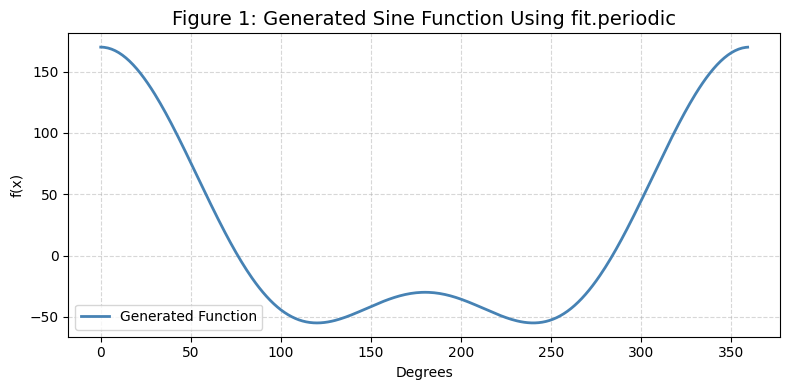

In [10]:
X = np.arange(360)                  # Generating x values
Params = [100, 90, 50, 45, 20]      # Arbitrary parameter values
fx = fit.periodic(X, *Params)           # Storing y values of function

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, fx, color="steelblue", linewidth=2, label="Generated Function")

ax.set_title("Figure 1: Generated Sine Function Using fit.periodic", fontsize=14)
ax.set_xlabel("Degrees")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### The periodic_fit function uses curve_fit to fit the periodic function for a given dataset. It returns an array of parameters and separately an array of associated errors in forms: [$A_1$,$\phi_1$,$A_2$,$\phi_2$,$C$] , [$\sigma_{A_1}$,$\sigma_{\phi_1}$,$\sigma_{A_2}$,$\sigma_{\phi_2}$,$\sigma_{C}$].
#### Initial guesses and bounds can be provided, but will use default arguments if not.
#### An example is provided below, where the function is fitted to a simulated dataset (See Sim demo notebook for more information). The result is shown in Figure 2:

The found parameters are [ 84.89869642  37.33466013  82.33417095 -76.01921166 260.01973116]
The calculated errors are [7.26643054 4.9039127  7.26643054 2.52832933 5.13814231]


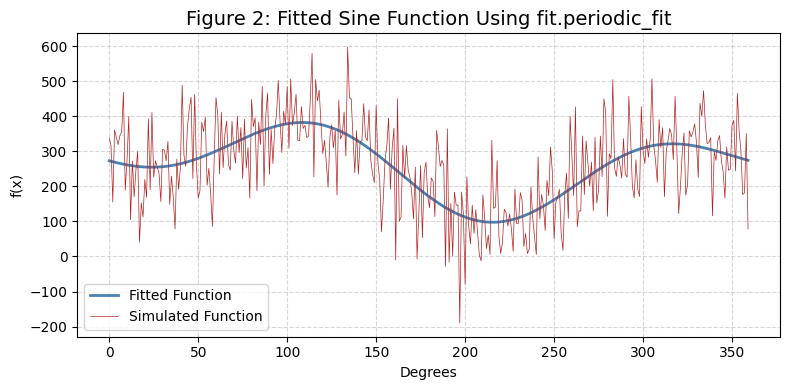

In [4]:
simulated_data = sim.sim_dataset(10,10,360,100,100, filesave= False, seed=100) # Simulating data, see Sim notebook

p0 = [1,1,1,1,1] # Inital Guesses
b0 = ([0,-180,0,-90,0],[1000,180,1000,90,1000]) # Bounds


## Using periodic_fit and unpacking params and errors
params, errors = fit.periodic_fit(X, simulated_data[0][0,0], initial = p0,bounds = b0) 

print(f"The found parameters are {params}")
print(f"The calculated errors are {errors}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, fit.periodic(X, *params), color="steelblue", linewidth=2, label="Fitted Function")
ax.plot(X, simulated_data[0][0,0], color="firebrick", linewidth=0.5, label="Simulated Function")

ax.set_title("Figure 2: Fitted Sine Function Using fit.periodic_fit", fontsize=14)
ax.set_xlabel("Degrees")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Finally, the periodic_fit_whole function iterates the periodic_fit function over each pixel in a dataset. This requires a 3-D dataset with the first two dimensions being spatial and a third spectral or temporal dimension.
#### Iterative fitting is available where the parameters from the previous pixel are the guesses for the next. This reduces computation time by ~30%.
#### Returns two arrays of shape (nx,ny,5) representing the params and errors for each pixel.

### An example run through on a simulated dataset (See Sim demo notebook for more information) is shown below, with visualizations of the parameters and errors in Figure 3 with a single pixel signal shown in Figure 4.  


In [36]:
simulated_dataset = sim.sim_dataset(50,50,360,100,100, filesave= False, seed=100) # Simulating data, see Sim notebook

p0 = [1,1,1,1,1] # Inital Guesses
b0 = ([0,-180,0,-90,0],[1000,180,1000,90,1000]) # Bounds

## Using periodic_fit and unpacking params and errors
params, errors = fit.periodic_fit_whole(simulated_dataset[0], p0, bounds =b0) 

Processing slices: 100%|██████████| 2500/2500 [00:30<00:00, 81.85it/s]


In [44]:
### Accessing params maps
A1_map = params[:,:,0]
phi1_map = params[:,:,1]
A2_map = params[:,:,2]
phi2_map = params[:,:,3]
offset_map = params[:,:,4]

### Accessing errors maps
A1_err_map = errors[:,:,0]
phi1_err_map = errors[:,:,1]
A2_err_map = errors[:,:,2]
phi2_err_map = errors[:,:,3]
offset_err_map = errors[:,:,4]

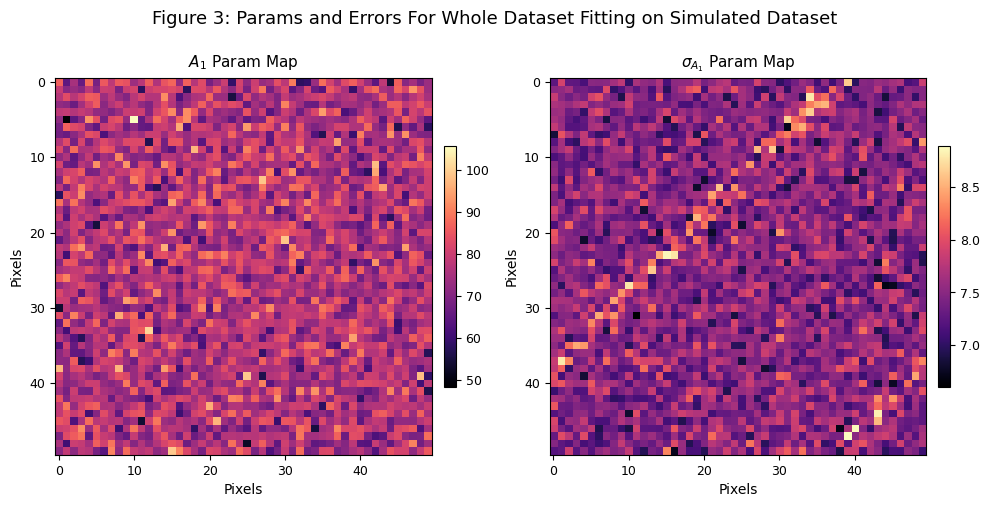

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

im0 = axes[0].imshow(A1_map, cmap="magma")

plt.suptitle("Figure 3: Params and Errors For Whole Dataset Fitting on Simulated Dataset", fontsize=13,y=0.9)

axes[0].set_title("$A_1$ Param Map", fontsize=11, pad=8)

im1 = axes[1].imshow(A1_err_map, cmap="magma")
axes[1].set_title("$\sigma_{A_1}$ Param Map", fontsize=11, pad=8)

for ax in axes:
    ax.set_xlabel("Pixels", fontsize=10)
    ax.set_ylabel("Pixels", fontsize=10)
    ax.tick_params(labelsize=9)

cb0 = fig.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.03)
cb1 = fig.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.03)
cb0.ax.tick_params(labelsize=9)
cb1.ax.tick_params(labelsize=9)

plt.tight_layout()

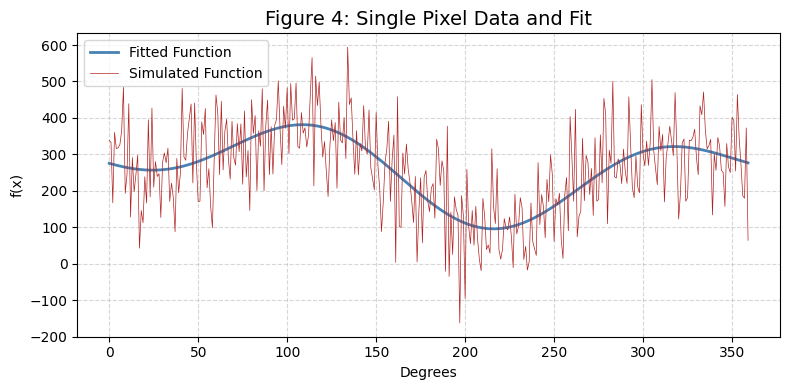

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, fit.periodic(X, *params[0,0,:]), color="steelblue", linewidth=2, label="Fitted Function")
ax.plot(X, simulated_dataset[0][0,0], color="firebrick", linewidth=0.5, label="Simulated Function")

ax.set_title("Figure 4: Single Pixel Data and Fit", fontsize=14)
ax.set_xlabel("Degrees")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()